[62, 58, 70, 70, 67, 59, 58, 62, 66, 59, 56, 63, 65, 58, 56, 59, 64, 60, 60, 61, 65, 65, 63, 59, 64, 65, 68, 66, 64, 67, 65]


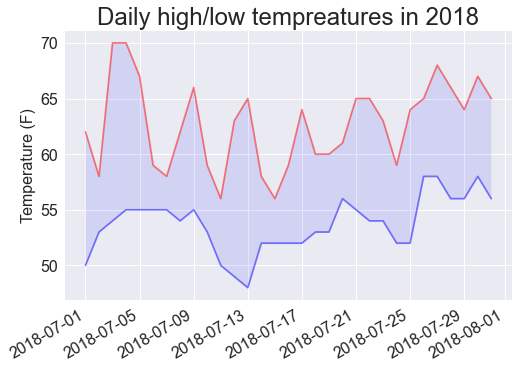

In [66]:
import csv
import matplotlib.pyplot as plt
from datetime import datetime

#filename = 'data/sitka_weather_07-2018_simple.csv'
filename = 'C:\\Users\\shaqu\\USWeather\\data\\sitka_weather_07-2018_simple.csv' #"C:\Users\shaqu\USWeather\data\sitka_weather_07-2018_simple.csv"
with open(filename) as f:
    reader = csv.reader(f)
    header_row = next(reader)
    #first_row = next(reader)

    # Get dates and high and low temperatures from this file.
    dates, highs, lows = [], [], []
    for row in reader:
        current_date = datetime.strptime(row[2],'%m/%d/%Y')#make sure date format matches exactly including commas, slashes, otherwise type value error
        high = int(row[5])
        low = int(row[6])
        dates.append(current_date)
        highs.append(high)
        lows.append(low)

    print(highs)

# Plot the high and low temperatures.
#plt.style.use('seaborn-v0_8') #np longer supported. see, line addition below
plt.style.use('seaborn')
fig, ax = plt.subplots()
ax.plot(dates,highs, c='red', alpha=0.5)
ax.plot(dates, lows, c='blue', alpha=0.5)
ax.fill_between(dates, highs, lows, facecolor='blue', alpha=0.1)

# Format the plot.
ax.set_title("Daily high/low tempreatures in 2018", fontsize=24)
ax.set_xlabel('',fontsize=16)
fig.autofmt_xdate()
ax.set_ylabel("Temperature (F)", fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=16)

plt.show()

    #for index, column_header, in enumerate(header_row):
    #    print(index, column_header)

    #print(header_row)
    #print(first_row)

New feature

In [64]:
#Average temperature in Sitka
import pandas 
data=pandas.read_csv('C:\\Users\\shaqu\\USWeather\\data\\sitka_weather_07-2018_simple.csv')
print(type(data)) #checking the type of dataframe
print(type(data['TMAX'])) #checking that python is reading this as a series
print(data)

def median_annual_temp(data):
    """Finds the annual mean temp through summing TMAX and TMIN, and dividing by the number of days in the year or month """
    TMAX = (data['TMAX'])
    print(TMAX.mean) #what is the logical way to find the mean; sum all values in TMAX and divide by length
    TMIN = (data['TMIN'])
    print(TMIN.mean)
    TMAX_len = (len(data['TMAX']))
    TMIN_len = (len(data['TMIN']))
           
    TMAX_TMIN_sum = TMAX_len + TMIN_len
    print(TMAX_TMIN_sum)
    


    
median_annual_temp(data)

#print(TMAX.mean) #this is probably because im trying to print something defined within the function

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>
        STATION                  NAME       DATE  PRCP  TAVG  TMAX  TMIN
0   USW00025333  SITKA AIRPORT, AK US   7/1/2018  0.25   NaN    62    50
1   USW00025333  SITKA AIRPORT, AK US   7/2/2018  0.01   NaN    58    53
2   USW00025333  SITKA AIRPORT, AK US   7/3/2018  0.00   NaN    70    54
3   USW00025333  SITKA AIRPORT, AK US   7/4/2018  0.00   NaN    70    55
4   USW00025333  SITKA AIRPORT, AK US   7/5/2018  0.00   NaN    67    55
5   USW00025333  SITKA AIRPORT, AK US   7/6/2018  0.00   NaN    59    55
6   USW00025333  SITKA AIRPORT, AK US   7/7/2018  0.00   NaN    58    55
7   USW00025333  SITKA AIRPORT, AK US   7/8/2018  0.00   NaN    62    54
8   USW00025333  SITKA AIRPORT, AK US   7/9/2018  0.00   NaN    66    55
9   USW00025333  SITKA AIRPORT, AK US  7/10/2018  0.44   NaN    59    53
10  USW00025333  SITKA AIRPORT, AK US  7/11/2018  0.29   NaN    56    50
11  USW00025333  SITKA AIRPORT, AK US  7/12/2018  

In [65]:
#New feature to select the date and to show you the temperature on that date
#Function to input date (make sure there is input validation)
def get_date():
    """Takes a date as user input and stores it as a variable"""
    year = int(input('Please enter a year:'))
    month = int(input('Please enter a month:'))
    day = int(input('Please enter a day:'))
    date = month,day,year
    return str(date) 
getdate = get_date() #remember to use in the next function need to store value so it can be used again.
print(getdate)
print('NOTE TO SELF: THIS WORKS AS INTENDED DONT BREAK IT')

Please enter a year:2018
Please enter a month:1
Please enter a day:7
(1, 7, 2018)
THIS WORKS AS INTENDED DONT BREAK IT


In [72]:
#Convert date into a string in the same format yyyy/mm/dd 
def make_string(getdate):
    """Converts value from date into a string in the same format as yyyy/mm/day, so it is in the same format as CSV"""
    formated_date = getdate.replace(',', '/').replace(' ','').replace('(','').replace(')','')
    return(formated_date)
result_to_take = make_string(getdate)
print(result_to_take)
print('NOTE TO SELF: THIS WORKS AS INTENDED DONT BREAK IT')
#print(result_to_take)

1/7/2018
THIS WORKS AS INTENDED DONT BREAK IT


In [73]:
print(result_to_take)

1/7/2018


In [74]:
print('This almost works, I just need it to return just the line with the corresponding date, rather than the whole column')
#Function to correspond the date entered to a date in the CSV file - to search data frame for the date
def get_the_max_and_min_temp(data):
    """Function to take the date and correspond to the max and min temp from the data""" #inherits from get_date
    for line in data['DATE']: #trying to access the column with the dates
        if line == result_to_take:
            return data['TMAX']
    else:
        print('Sorry this date is from before records began')
max_temp_on_chosen_date = get_the_max_and_min_temp(data)


This almost works, I just need it to return just the line with the corresponding date, rather than the whole column
Sorry this date is from before records began


In [81]:
# Imports
import tkinter as tk
from tkinter import ttk
#import ttkbootstrap as ttk

# Setup
window = tk.Tk()
window.title('What was the temperature?')
window.geometry('600x400')
# Widgets
widget = ttk.Label(master=window, text='The maximum temperature on your chosen date was:')
print(max_temp_on_chosen_date) #not running correctly, I want this to print out the variable in the window

# Layout
widget.pack()  # places text within the GUI window

# Run
window.mainloop()  # starts event loop

print('NOTE TO SELF: NOT RUNNING AS INTENDED: I WANT TO PRINT OUT THE VARIABLE IN LINE 12 ON THE WINDOW')

None
